In [57]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.io import loadmat
from time import time
import tensorflow_probability as tfp

print ( tf.config.list_physical_devices ( 'GPU' ) )
print ( "Libraries imported" )

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Libraries imported


In [58]:
adam_epochs = 15000

In [59]:
cylinder_wake = loadmat ( "cylinder_nektar_wake.mat" )
print ( cylinder_wake.keys() )

X_star = cylinder_wake['X_star']
t = cylinder_wake['t']
U_star = cylinder_wake['U_star']
p_star = cylinder_wake['p_star']

print ( X_star.shape, t.shape, U_star.shape, p_star.shape )

dict_keys(['__header__', '__version__', '__globals__', 'X_star', 't', 'U_star', 'p_star'])
(5000, 2) (200, 1) (5000, 2, 200) (5000, 200)


In [60]:
N = 5000

x = X_star[:, 0:1]
y = X_star[:, 1:2]

x_repeat = np.tile ( x, ( 1, t.shape[0] ) )
y_repeat = np.tile ( y, ( 1, t.shape[0] ) )
t_repeat = np.tile ( t.T, ( x.shape[0], 1 ) )

X_T = np.hstack ( [ x_repeat.reshape ( -1, 1 ), y_repeat.reshape ( -1, 1 ), t_repeat.reshape ( -1, 1 ) ] )

u = U_star[:, 0, :].reshape ( -1, 1 )
v = U_star[:, 1, :].reshape ( -1, 1 )
p = p_star.reshape ( -1, 1 )

rows = X_T.shape[0]

rng = np.random.default_rng()
indices = rng.choice ( np.arange ( 0, rows ), size = N, replace = False )

# For data loss

x_train = X_T[indices]
y_train = np.hstack ( [ u[indices], v[indices] ] )

# For collocation point loss

x_tf = tf.convert_to_tensor ( x_train[:, 0:1], dtype = tf.float32 )
y_tf = tf.convert_to_tensor ( x_train[:, 1:2], dtype = tf.float32 )
t_tf = tf.convert_to_tensor ( x_train[:, 2:3], dtype = tf.float32 )

print ( x_train.shape, y_train.shape, p_train.shape )
print ( x_tf.shape, y_tf.shape, t_tf.shape )

(5000, 3) (5000, 2) (5000, 1)
(5000, 1) (5000, 1) (5000, 1)


In [61]:
lambda_1 = tf.Variable ( 0.0, dtype = tf.float32, name = "lambda_1" )
lambda_2 = tf.Variable ( 0.0, dtype = tf.float32, name = "lambda_2" )

In [62]:
model = tf.keras.Sequential ( [
        tf.keras.layers.InputLayer ( input_shape = ( 3, ) ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 100, activation = 'tanh', kernel_initializer = tf.initializers.GlorotUniform() ),
        tf.keras.layers.Dense ( 2 )
    ] )

print ( model.summary() )

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 100)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,402 (317.98 KB)

 Trainable params: 81,402 (317.98 KB)

 Non-trainable params: 0 (0.00 B)

None


In [63]:

@tf.function
def MSE_b():
    with tf.GradientTape ( persistent = True ) as tape:
        tape.watch ( [ x_tf, y_tf, t_tf ] )

        pred = model ( tf.concat ( [ x_tf, y_tf, t_tf ], axis = 1 ) )
        psi = pred[:, 0:1]
        
    u_pred = tape.gradient ( psi, y_tf )
    v_pred = (-1) * tape.gradient ( psi, x_tf )

    vel_pred = tf.keras.ops.hstack ( [ u_pred, v_pred ] )
                       
    del tape
    return tf.reduce_mean ( tf.square ( vel_pred - y_train ) )

@tf.function
def MSE_f():
    with tf.GradientTape ( persistent = True ) as tape3:
        tape3.watch ( [ x_tf, y_tf, t_tf ] )
        with tf.GradientTape ( persistent = True ) as tape2:
            tape2.watch ( [ x_tf, y_tf, t_tf ] )
            with tf.GradientTape ( persistent = True ) as tape1:
                tape1.watch ( [ x_tf, y_tf, t_tf ] )

                pred = model ( tf.concat ( [ x_tf, y_tf, t_tf ], axis = 1 ) )

                psi = pred[:, 0:1]
                p = pred[:, 1:2]

            u_pred = tape1.gradient ( psi, y_tf )
            v_pred = (-1) * tape1.gradient ( psi, x_tf )

            p_x = tape1.gradient ( p, x_tf )
            p_y = tape1.gradient ( p, y_tf )

        u_t = tape2.gradient ( u_pred, t_tf )
        v_t = tape2.gradient ( v_pred, t_tf )
        u_x = tape2.gradient ( u_pred, x_tf )
        v_x = tape2.gradient ( v_pred, x_tf )
        u_y = tape2.gradient ( u_pred, y_tf )
        v_y = tape2.gradient ( v_pred, y_tf )

    u_xx = tape3.gradient ( u_x, x_tf )
    v_xx = tape3.gradient ( v_x, x_tf )
    u_yy = tape3.gradient ( u_y, y_tf )
    v_yy = tape3.gradient ( v_y, y_tf )

    f = u_t + lambda_1 * ( u_pred * u_x + v_pred * u_y ) + p_x - lambda_2 * ( u_xx + u_yy )
    g = v_t + lambda_1 * ( u_pred * v_x + v_pred * v_y ) + p_y - lambda_2 * ( v_xx + v_yy )
    
    del tape1, tape2, tape3
    return tf.reduce_mean ( tf.square ( f ) + tf.square ( g ) )

print ( MSE_b(), MSE_f() )

tf.Tensor(0.5075619, shape=(), dtype=float32) tf.Tensor(0.0075489935, shape=(), dtype=float32)


In [64]:

opt = tf.keras.optimizers.AdamW ( learning_rate = 1e-3, weight_decay = 0.0 )

print ( "INFO: Training Started" )
start = time()

for epoch in range ( 1, adam_epochs + 1 ):
    with tf.GradientTape() as tape:
        loss_b = MSE_b()
        loss_f = MSE_f()
        loss = loss_b + loss_f

    all_trainable_vars = model.trainable_variables + [ lambda_1, lambda_2 ]

    grads = tape.gradient ( loss, all_trainable_vars )
    opt.apply_gradients ( zip ( grads, all_trainable_vars ) )
    
    if ( epoch % 1000 == 0 ):
        print ( "INFO: Adam Epoch {} reached; Time elapsed: {}\nlambda_1: {}; lambda_2: {}\nMSE_b : {}, MSE_f: {}\n".format ( str ( epoch ), str ( time() - start ), str ( lambda_1.numpy() ), str ( lambda_2.numpy() ), str ( float ( loss_b ) ), str ( float ( loss_f ) ) ) )

    if ( epoch == 5000 ):
        print ( "INFO: Adam Learning rate now 0.0001 and decay 0.0001" )
        opt.learning_rate.assign ( 1e-4 )
        opt.weight_decay = 1e-4

    if ( epoch == 10000 ):
        print ( "INFO: Adam Learning rate now 0.00001" )
        opt.learning_rate.assign ( 1e-5 )
        opt.weight_decay = 1e-4

print ( "INFO: Training with Adam done" )


INFO: Training Started


/home/aadharsh/venv/lib/python3.10/site-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['sequential_5/dense_59/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


INFO: Adam Epoch 1000 reached; Time elapsed: 62.12540078163147
lambda_1: 0.93835497; lambda_2: 0.016925504
MSE_b : 0.004528584890067577, MSE_f: 0.0016637846129015088

INFO: Adam Epoch 2000 reached; Time elapsed: 122.20937013626099
lambda_1: 0.98567724; lambda_2: 0.012389668
MSE_b : 0.0004986094427295029, MSE_f: 0.00039927285979501903

INFO: Adam Epoch 3000 reached; Time elapsed: 183.8473994731903
lambda_1: 0.9932568; lambda_2: 0.011357002
MSE_b : 0.00035957610816694796, MSE_f: 0.0002973444643430412

INFO: Adam Epoch 4000 reached; Time elapsed: 247.47973084449768
lambda_1: 0.99530363; lambda_2: 0.011056643
MSE_b : 0.00032800427288748324, MSE_f: 0.0002033975615631789

INFO: Adam Epoch 5000 reached; Time elapsed: 315.0682849884033
lambda_1: 0.99681926; lambda_2: 0.01086185
MSE_b : 0.00012288983270991594, MSE_f: 0.0001116529674618505

INFO: Adam Learning rate now 0.0001 and decay 0.0001
INFO: Adam Epoch 6000 reached; Time elapsed: 378.62151432037354
lambda_1: 0.99773914; lambda_2: 0.010860

In [103]:
# Velocity L2 relative error calculation

vel_soln = np.hstack ( [ u, v ] )

x_all = tf.convert_to_tensor ( x_repeat.flatten().reshape ( -1, 1 ), dtype = tf.float32 )
y_all = tf.convert_to_tensor ( y_repeat.flatten().reshape ( -1, 1 ), dtype = tf.float32 )
t_all = tf.convert_to_tensor ( t_repeat.flatten().reshape ( -1, 1 ), dtype = tf.float32 )

with tf.GradientTape ( persistent = True ) as tape:
    tape.watch ( [ x_all, y_all, t_all ] )
    model_pred = model ( tf.concat ( [ x_all, y_all, t_all ], axis = 1 )  )
    psi_pred = model_pred[:, 0:1]

u_pred = tape.gradient ( psi_pred, y_all )
v_pred = (-1) * tape.gradient ( psi_pred, x_all )

vel_pred = np.hstack ( [ u_pred, v_pred ] )

print ( x_all.shape, y_all.shape, t_all.shape, exact_soln.shape, model_pred.shape )

vel_error = np.linalg.norm ( vel_pred - vel_soln ) / np.linalg.norm ( vel_soln )

print ( "\nVelocity relative L2 Error:", vel_error )

(1000000, 1) (1000000, 1) (1000000, 1) (1000000, 2) (1000000, 2)

Velocity relative L2 Error: 0.008693176946233469


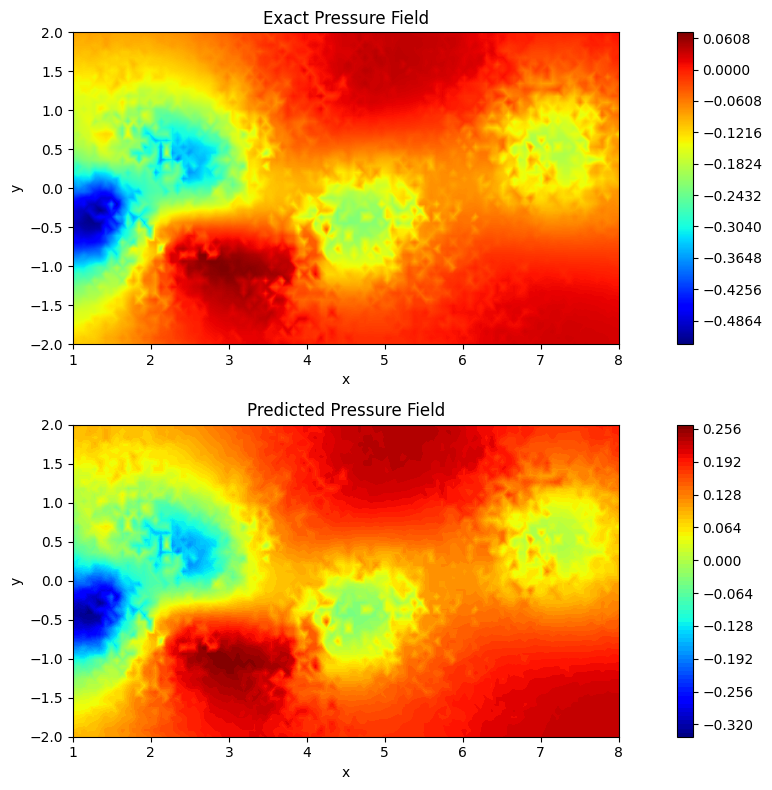

0.6089495361212589 0.6625


In [148]:

pressure_exact = p_star.flatten()
pressure_pred = model_pred[:, 1:2].numpy().reshape ( pressure_exact.shape )

fig, ax = plt.subplots ( 2, 1, figsize = ( 12, 8 ) )

contour_exact = ax[0].tricontourf ( x_repeat.flatten(), y_repeat.flatten(), pressure_exact, levels = 1000, cmap = 'jet' )
fig.colorbar ( contour_exact, ax = ax[0] )
ax[0].set_title ( 'Exact Pressure Field' )
ax[0].set_xlabel ( 'x' )
ax[0].set_ylabel ( 'y' )
ax[0].set_aspect ( 'equal' )

contour_pred = ax[1].tricontourf ( x_repeat.flatten(), y_repeat.flatten(), pressure_pred, levels = 100, cmap = 'jet' )
fig.colorbar ( contour_pred, ax = ax[1] )
ax[1].set_title ( 'Predicted Pressure Field' )
ax[1].set_xlabel ( 'x' )
ax[1].set_ylabel ( 'y' )
ax[1].set_aspect ( 'equal' )

plt.tight_layout()
plt.show()

print ( pressure_exact.max() - pressure_exact.min(), pressure_pred.max() - pressure_pred.min() )

In [149]:
print ( "Exact lambda values:\nlambda_1: 1, lambda_2: 0.01" )
print ( "\nFinal predicted lambda values:\nlambda_1: {}, lambda_2: {}".format ( lambda_1.numpy(), lambda_2.numpy() ) )

Exact lambda values:
lambda_1: 1, lambda_2: 0.01

Final predicted lambda values:
lambda_1: 0.9994705319404602, lambda_2: 0.010671190917491913
